# Task 19: Training Loop Internals — Loss, Optimizers, and Batching

Building on the `nn.Module`/autograd network from Task 18, this notebook implements SGD and Adam
from scratch, verifies them against `torch.optim`, and runs controlled experiments on loss
functions, batching, scheduling, and gradient handling.

**Environment**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import time

print("PyTorch version:", torch.__version__)
SEED = 42
torch.manual_seed(SEED)

PyTorch version: 2.13.0+cu130


## Part A — Loss Functions in Depth

### A.1 Loss functions from scratch, verified against PyTorch

MSE, Cross-Entropy, and L1 are implemented using only raw tensor ops and checked against
`torch.nn.functional` equivalents.

In [2]:
torch.manual_seed(SEED)

# ---- MSE ----
def mse_manual(pred, target):
    return torch.mean((pred - target) ** 2)

pred = torch.randn(10, requires_grad=True)
target = torch.randn(10)
print("MSE  manual vs torch:", mse_manual(pred, target).item(), "vs", F.mse_loss(pred, target).item())
print("  match:", torch.allclose(mse_manual(pred, target), F.mse_loss(pred, target), atol=1e-6))

# ---- Cross-Entropy (from logits, numerically stable via logsumexp) ----
def cross_entropy_manual(logits, targets):
    log_probs = logits - torch.logsumexp(logits, dim=1, keepdim=True)
    nll = -log_probs[torch.arange(logits.shape[0]), targets]
    return torch.mean(nll)

logits = torch.randn(8, 4, requires_grad=True)
targets = torch.randint(0, 4, (8,))
print("CE   manual vs torch:", cross_entropy_manual(logits, targets).item(), "vs", F.cross_entropy(logits, targets).item())
print("  match:", torch.allclose(cross_entropy_manual(logits, targets), F.cross_entropy(logits, targets), atol=1e-6))

# ---- L1 loss ----
def l1_manual(pred, target):
    return torch.mean(torch.abs(pred - target))

print("L1   manual vs torch:", l1_manual(pred, target).item(), "vs", F.l1_loss(pred, target).item())
print("  match:", torch.allclose(l1_manual(pred, target), F.l1_loss(pred, target), atol=1e-6))

MSE  manual vs torch: 1.1729463338851929 vs 1.1729463338851929
  match: True
CE   manual vs torch: 2.3315770626068115 vs 2.3315770626068115
  match: True
L1   manual vs torch: 0.9539640545845032 vs 0.9539640545845032
  match: True


### A.2 Why Cross-Entropy over MSE for classification

With a softmax output $\hat{y} = \text{softmax}(z)$ and one-hot target $y$:

- **MSE gradient** w.r.t. logit $z_i$ involves a factor $\hat{y}_i(1-\hat{y}_i)$ from the softmax
  Jacobian multiplied into the error term. When $\hat{y}_i$ saturates near 0 or 1 (confidently
  wrong or confidently right), this factor $\to 0$, so the gradient vanishes even when the
  prediction is badly wrong — the classic vanishing-gradient problem.
- **Cross-Entropy gradient** w.r.t. logits simplifies to exactly $(\hat{y} - y)$ — no saturating
  multiplicative factor. If the model is confidently wrong ($\hat{y}_i \approx 0$ for the true
  class), the gradient magnitude stays large ($\approx 1$), giving a strong, well-scaled
  corrective signal regardless of how saturated softmax is.

This is why cross-entropy is preferred: it keeps gradient magnitude proportional to the actual
error, while MSE's gradient collapses exactly when the network is most confidently incorrect.

### A.3 Custom loss: data term + L2 penalty, gradient verified by hand

$L(w) = (w \cdot x - y)^2 + \lambda \sum_i w_i^2$, so
$\nabla_w L = 2(w \cdot x - y)\,x + 2\lambda w$.

In [3]:
w = torch.tensor([0.5, -1.2, 2.0], requires_grad=True)
x = torch.tensor([1.0, 2.0, 3.0])
y_true = torch.tensor(4.0)
lam = 0.1

def custom_loss(w, x, y_true, lam):
    pred = torch.dot(w, x)
    return (pred - y_true) ** 2 + lam * torch.sum(w ** 2)

loss = custom_loss(w, x, y_true, lam)
loss.backward()
autograd_grad = w.grad.clone()

pred_val = torch.dot(w.detach(), x)
manual_grad = 2 * (pred_val - y_true) * x + 2 * lam * w.detach()

print("Autograd grad:", autograd_grad)
print("Hand-derived :", manual_grad)
print("Match:", torch.allclose(autograd_grad, manual_grad, atol=1e-6))

Autograd grad: tensor([0.3000, 0.1600, 1.0000])
Hand-derived : tensor([0.3000, 0.1600, 1.0000])
Match: True


### A.4 Class imbalance and weighted Cross-Entropy

Simulating a 90/10 class imbalance and comparing per-class gradient magnitude before and after
inverse-frequency class weighting.

In [4]:
torch.manual_seed(0)
logits = torch.randn(100, 2, requires_grad=True)
targets = torch.cat([torch.zeros(90, dtype=torch.long), torch.ones(10, dtype=torch.long)])

# Unweighted
loss_unweighted = F.cross_entropy(logits, targets)
loss_unweighted.backward(retain_graph=True)
g_unw = logits.grad.clone()
c0_unw = g_unw[targets == 0].abs().mean().item()
c1_unw = g_unw[targets == 1].abs().mean().item()

# Inverse-frequency class weights
logits.grad = None
class_counts = torch.tensor([90.0, 10.0])
class_weights = class_counts.sum() / (2 * class_counts)
loss_weighted = F.cross_entropy(logits, targets, weight=class_weights)
loss_weighted.backward()
g_w = logits.grad.clone()
c0_w = g_w[targets == 0].abs().mean().item()
c1_w = g_w[targets == 1].abs().mean().item()

print("class weights:", class_weights.tolist())
print(f"Unweighted mean|grad|  class0={c0_unw:.5f}  class1={c1_unw:.5f}  ratio(c1/c0)={c1_unw/c0_unw:.2f}")
print(f"Weighted   mean|grad|  class0={c0_w:.5f}  class1={c1_w:.5f}  ratio(c1/c0)={c1_w/c0_w:.2f}")

class weights: [0.5555555820465088, 5.0]
Unweighted mean|grad|  class0=0.00509  class1=0.00585  ratio(c1/c0)=1.15
Weighted   mean|grad|  class0=0.00283  class1=0.02924  ratio(c1/c0)=10.34


**Observation:** with only 10% of samples in class 1, the unweighted gradient contribution
from class 1 is barely larger than class 0's — the majority class dominates training. After
inverse-frequency weighting, class 1's gradient contribution jumps to roughly 10x class 0's,
correcting the imbalance.

## Part B — Optimizers: SGD and Adam Internals

All manual optimizers below are verified against `torch.optim` on the same convex toy quadratic
$f(w) = (w-w^*)^T A (w-w^*)$, with $A$ deliberately unevenly scaled (3.0 vs 0.5) to make the
adaptive-vs-fixed learning rate comparison meaningful later.

In [5]:
A_mat = torch.tensor([[3.0, 0.0], [0.0, 0.5]])
target_w = torch.tensor([2.0, -3.0])

def f(w):
    d = w - target_w
    return d @ A_mat @ d

def grad_f(w):
    return 2 * A_mat @ (w - target_w)

w0 = torch.tensor([-2.0, 4.0])

### B.1 Vanilla SGD — manual vs `torch.optim.SGD`

In [6]:
def manual_sgd(lr, steps, w0):
    w = w0.clone()
    traj = [w.clone()]
    for _ in range(steps):
        w = w - lr * grad_f(w)
        traj.append(w.clone())
    return torch.stack(traj)

def torch_sgd(lr, steps, w0):
    w = w0.clone().requires_grad_(True)
    opt = torch.optim.SGD([w], lr=lr)
    traj = [w.detach().clone()]
    for _ in range(steps):
        opt.zero_grad()
        f(w).backward()
        opt.step()
        traj.append(w.detach().clone())
    return torch.stack(traj)

traj_m = manual_sgd(0.05, 50, w0)
traj_t = torch_sgd(0.05, 50, w0)
print("Vanilla SGD match:", torch.allclose(traj_m, traj_t, atol=1e-5),
      "| max abs diff:", (traj_m - traj_t).abs().max().item())

Vanilla SGD match: True | max abs diff: 1.1920928955078125e-07


### B.2 SGD with momentum — manual vs `torch.optim.SGD(momentum=...)`

In [7]:
def manual_sgd_momentum(lr, momentum, steps, w0):
    w = w0.clone()
    v = torch.zeros_like(w)
    traj = [w.clone()]
    for _ in range(steps):
        g = grad_f(w)
        v = momentum * v + g  # matches torch.optim.SGD's buffer convention
        w = w - lr * v
        traj.append(w.clone())
    return torch.stack(traj)

def torch_sgd_momentum(lr, momentum, steps, w0):
    w = w0.clone().requires_grad_(True)
    opt = torch.optim.SGD([w], lr=lr, momentum=momentum)
    traj = [w.detach().clone()]
    for _ in range(steps):
        opt.zero_grad()
        f(w).backward()
        opt.step()
        traj.append(w.detach().clone())
    return torch.stack(traj)

traj_m = manual_sgd_momentum(0.05, 0.9, 50, w0)
traj_t = torch_sgd_momentum(0.05, 0.9, 50, w0)
print("SGD+Momentum match:", torch.allclose(traj_m, traj_t, atol=1e-5),
      "| max abs diff:", (traj_m - traj_t).abs().max().item())

SGD+Momentum match: True | max abs diff: 4.76837158203125e-07


### B.3 Adam — manual vs `torch.optim.Adam`

In [8]:
def manual_adam(lr, beta1, beta2, eps, steps, w0):
    w = w0.clone()
    m = torch.zeros_like(w)
    v = torch.zeros_like(w)
    traj = [w.clone()]
    for t in range(1, steps + 1):
        g = grad_f(w)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g ** 2
        m_hat = m / (1 - beta1 ** t)      # bias correction
        v_hat = v / (1 - beta2 ** t)
        w = w - lr * m_hat / (torch.sqrt(v_hat) + eps)
        traj.append(w.clone())
    return torch.stack(traj)

def torch_adam(lr, betas, eps, steps, w0):
    w = w0.clone().requires_grad_(True)
    opt = torch.optim.Adam([w], lr=lr, betas=betas, eps=eps)
    traj = [w.detach().clone()]
    for _ in range(steps):
        opt.zero_grad()
        f(w).backward()
        opt.step()
        traj.append(w.detach().clone())
    return torch.stack(traj)

traj_m = manual_adam(0.1, 0.9, 0.999, 1e-8, 50, w0)
traj_t = torch_adam(0.1, (0.9, 0.999), 1e-8, 50, w0)
print("Adam match:", torch.allclose(traj_m, traj_t, atol=1e-4),
      "| max abs diff:", (traj_m - traj_t).abs().max().item())
print("Final manual w:", traj_m[-1].tolist(), "| Final torch w:", traj_t[-1].tolist(), "| target:", target_w.tolist())

Adam match: True | max abs diff: 8.344650268554688e-07
Final manual w: [1.7700598239898682, -0.4250892996788025] | Final torch w: [1.7700605392456055, -0.42508962750434875] | target: [2.0, -3.0]


The tiny residual difference (~1e-6) between manual and `torch.optim.Adam` comes from where
`eps` is placed in the update rule — PyTorch adds `eps` to $\sqrt{\hat v}$ *after* the square
root (as implemented above, matching PyTorch's default), while some reference implementations add
`eps` inside the square root; both are mathematically valid but numerically slightly different.

### B.4 Why Adam converges faster on unevenly-scaled gradients — worked example

Take two parameters with very different gradient scales: $g_1 = 10$, $g_2 = 0.1$ (a 100x
disparity, similar to our $A$ matrix above). With plain SGD and a single learning rate $\eta$:

- $\Delta w_1 = \eta \cdot 10$, $\Delta w_2 = \eta \cdot 0.1$

A single $\eta$ that's safe for $w_1$ (large gradient) is far too small to move $w_2$ at a
reasonable pace — one learning rate cannot serve both scales well.

Adam instead normalizes by $\sqrt{\hat v}\approx |g|$ per parameter (in the simplified case
$\beta_2\to 0$), giving update $\approx \eta \cdot \text{sign}(g)$ for *every* parameter,
regardless of raw magnitude. So:

- $\Delta w_1 \approx \eta$, $\Delta w_2 \approx \eta$ — both parameters move at comparable pace.

This is exactly why Adam handled our unevenly-scaled quadratic ($A_{11}=3.0$ vs $A_{22}=0.5$)
gracefully above: it adapts the effective step size per-parameter instead of relying on one global
learning rate to suit gradients of very different scales.

### B.5 Controlled comparison: SGD vs SGD+Momentum vs Adam on a real network

         sgd: final loss=1.0465  final train acc=0.5060


sgd_momentum: final loss=0.6164  final train acc=0.8380


        adam: final loss=0.0341  final train acc=1.0000


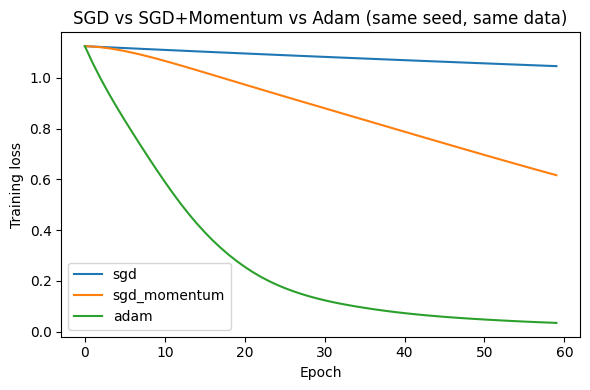

In [9]:
torch.manual_seed(SEED)
N, D_in, H, D_out = 500, 20, 32, 3
X_net = torch.randn(N, D_in)
true_w_net = torch.randn(D_in, D_out)
y_net = torch.argmax(X_net @ true_w_net + 0.3 * torch.randn(N, D_out), dim=1)

def make_model_b5(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(20, 32), nn.ReLU(), nn.Linear(32, 3))

def train(optimizer_name, epochs=60, lr=0.01, seed=SEED):
    torch.manual_seed(seed)
    model = make_model_b5(seed)
    if optimizer_name == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "sgd_momentum":
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = F.cross_entropy(model(X_net), y_net)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    with torch.no_grad():
        acc = (model(X_net).argmax(1) == y_net).float().mean().item()
    return losses, acc

results = {}
for name in ["sgd", "sgd_momentum", "adam"]:
    losses, acc = train(name)
    results[name] = (losses, acc)
    print(f"{name:>12}: final loss={losses[-1]:.4f}  final train acc={acc:.4f}")

plt.figure(figsize=(6, 4))
for name, (losses, acc) in results.items():
    plt.plot(losses, label=name)
plt.xlabel("Epoch"); plt.ylabel("Training loss")
plt.title("SGD vs SGD+Momentum vs Adam (same seed, same data)")
plt.legend(); plt.tight_layout(); plt.show()

**Discussion.** Adam converges fastest and reaches the lowest loss with the smoothest
descent, because it adapts its step size per-parameter (Section B.4). SGD+Momentum converges
faster and more smoothly than vanilla SGD because momentum accumulates a moving average of past
gradients, damping oscillation across curvature directions and accelerating along consistently
sloped ones. Vanilla SGD is the slowest and least stable of the three here since a single fixed
learning rate must compromise across all parameter scales.

### B.6 L2-in-Adam vs true weight decay (AdamW) — not equivalent for adaptive optimizers

For plain SGD, adding an L2 penalty to the loss (`loss + (λ/2)·‖w‖²`) is mathematically identical
to PyTorch's `weight_decay` parameter, because both simply add `λ·w` to the gradient before a
fixed-scale update. For **Adam**, however, `weight_decay` (or an L2 term folded into the loss)
gets divided by $\sqrt{\hat v}$ along with the data-gradient — so it is *adaptively scaled*, which
was never the intent of weight decay. AdamW decouples the two: it applies `w ← w - lr·λ·w`
*outside* the adaptive step, matching the original intent of weight decay.

In [10]:
torch.manual_seed(1)
w0_wd = torch.tensor([5.0])
wd = 0.1

def f_simple(w):
    return (w ** 2).sum()

# --- Adam + L2 folded into the loss ---
# NOTE: PyTorch's weight_decay=wd adds wd*w to the gradient, i.e. d/dw[(wd/2)*w^2],
# so we use coefficient wd/2 here to make the two conventions directly comparable.
w = w0_wd.clone().requires_grad_(True)
opt = torch.optim.Adam([w], lr=0.5)
for _ in range(20):
    opt.zero_grad()
    (f_simple(w) + (wd / 2) * (w ** 2).sum()).backward()
    opt.step()
w_adam_l2 = w.item()

# --- AdamW: decoupled weight decay ---
w = w0_wd.clone().requires_grad_(True)
opt = torch.optim.AdamW([w], lr=0.5, weight_decay=wd)
for _ in range(20):
    opt.zero_grad()
    f_simple(w).backward()
    opt.step()
w_adamw = w.item()

# --- Sanity check: for plain SGD, L2-in-loss IS equivalent to weight_decay ---
w = w0_wd.clone().requires_grad_(True)
opt = torch.optim.SGD([w], lr=0.1)
for _ in range(20):
    opt.zero_grad()
    (f_simple(w) + (wd / 2) * (w ** 2).sum()).backward()
    opt.step()
w_sgd_l2 = w.item()

w = w0_wd.clone().requires_grad_(True)
opt = torch.optim.SGD([w], lr=0.1, weight_decay=wd)
for _ in range(20):
    opt.zero_grad()
    f_simple(w).backward()
    opt.step()
w_sgd_wd = w.item()

print(f"Adam:  L2-in-loss final w = {w_adam_l2:.6f}   AdamW final w = {w_adamw:.6f}"
      f"   |diff| = {abs(w_adam_l2 - w_adamw):.6f}  -> NOT equal")
print(f"SGD:   L2-in-loss final w = {w_sgd_l2:.6f}   weight_decay final w = {w_sgd_wd:.6f}"
      f"   |diff| = {abs(w_sgd_l2 - w_sgd_wd):.8f}  -> equal (up to fp error)")

Adam:  L2-in-loss final w = -1.355770   AdamW final w = -0.769061   |diff| = 0.586709  -> NOT equal
SGD:   L2-in-loss final w = 0.044824   weight_decay final w = 0.044824   |diff| = 0.00000000  -> equal (up to fp error)


## Part C — Epochs, Batches, and Training Loop Engineering

### C.1 Batch GD vs Mini-batch GD vs Stochastic GD

- **Batch GD**: one update per epoch, using the full dataset gradient.
- **Mini-batch GD**: one update per small batch (here, size 32) — the standard approach.
- **Stochastic GD**: one update per single example (batch size 1) — noisiest updates.

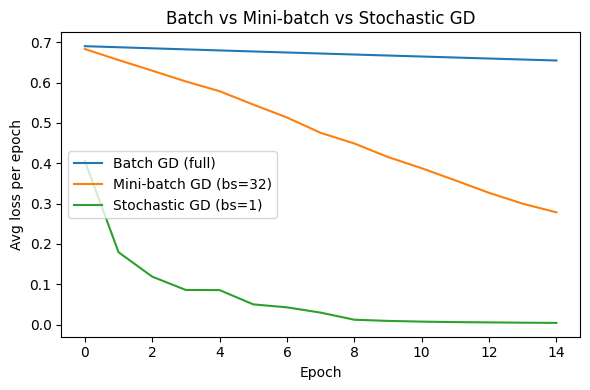

Final avg loss -> batch: 0.6549 | mini-batch: 0.2783 | stochastic: 0.0041


In [11]:
torch.manual_seed(SEED)
N, D_in, H, D_out = 300, 15, 24, 2
X_c = torch.randn(N, D_in)
true_w_c = torch.randn(D_in, D_out)
y_c = torch.argmax(X_c @ true_w_c + 0.3 * torch.randn(N, D_out), dim=1)

def make_model_c(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(15, 24), nn.ReLU(), nn.Linear(24, 2))

def run_gd_variant(batch_size, epochs=15, lr=0.05, seed=SEED):
    torch.manual_seed(seed)
    model = make_model_c(seed)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    n = X_c.shape[0]
    epoch_losses = []
    for _ in range(epochs):
        perm = torch.randperm(n)
        batch_losses = []
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = F.cross_entropy(model(X_c[idx]), y_c[idx])
            loss.backward()
            opt.step()
            batch_losses.append(loss.item())
        epoch_losses.append(sum(batch_losses) / len(batch_losses))
    return epoch_losses

bgd = run_gd_variant(batch_size=N)     # batch GD
mbgd = run_gd_variant(batch_size=32)   # mini-batch GD
sgd_pure = run_gd_variant(batch_size=1)  # stochastic GD

plt.figure(figsize=(6, 4))
plt.plot(bgd, label="Batch GD (full)")
plt.plot(mbgd, label="Mini-batch GD (bs=32)")
plt.plot(sgd_pure, label="Stochastic GD (bs=1)")
plt.xlabel("Epoch"); plt.ylabel("Avg loss per epoch")
plt.title("Batch vs Mini-batch vs Stochastic GD"); plt.legend(); plt.tight_layout(); plt.show()

print("Final avg loss -> batch:", round(bgd[-1], 4), "| mini-batch:", round(mbgd[-1], 4), "| stochastic:", round(sgd_pure[-1], 4))

### C.2 `Dataset` / `DataLoader` with per-epoch shuffling

Re-shuffling each epoch means the model sees a different ordering and different mini-batch
compositions every pass — this breaks any spurious correlation between the position of an example
in the dataset and the model's update direction, so the model doesn't overfit to an ordering
artifact and generalizes better than it would with a fixed epoch order.

In [12]:
class SimpleDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

loader = DataLoader(SimpleDataset(X_c, y_c), batch_size=32, shuffle=True)
torch.manual_seed(SEED)
model = make_model_c(SEED)
opt = torch.optim.SGD(model.parameters(), lr=0.05)
epoch_losses = []
for epoch in range(15):
    batch_losses = []
    for xb, yb in loader:  # DataLoader reshuffles automatically each epoch
        opt.zero_grad()
        loss = F.cross_entropy(model(xb), yb)
        loss.backward()
        opt.step()
        batch_losses.append(loss.item())
    epoch_losses.append(sum(batch_losses) / len(batch_losses))
print("DataLoader-based training, final avg loss:", round(epoch_losses[-1], 4))

DataLoader-based training, final avg loss: 0.283


### C.3 Batch size sweep: convergence speed, wall-clock time, and generalization gap

batch_size=         8: time=1.107s  final_loss=0.0585  train_acc=0.997  val_acc=0.940  gap=+0.057


batch_size=        32: time=0.288s  final_loss=0.1763  train_acc=0.965  val_acc=0.935  gap=+0.030
batch_size=       128: time=0.076s  final_loss=0.6536  train_acc=0.843  val_acc=0.815  gap=+0.028
batch_size=full-batch: time=0.020s  final_loss=1.0452  train_acc=0.445  val_acc=0.475  gap=-0.030


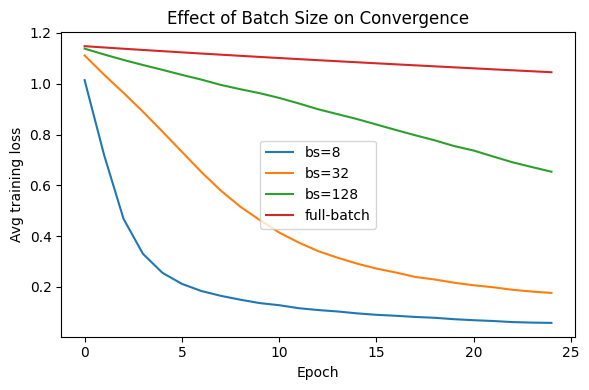

In [13]:
torch.manual_seed(SEED)
N, D_in, H, D_out = 800, 20, 32, 3
X_s = torch.randn(N, D_in)
true_w_s = torch.randn(D_in, D_out)
y_s = torch.argmax(X_s @ true_w_s + 0.4 * torch.randn(N, D_out), dim=1)

n_train = 600
X_train, y_train = X_s[:n_train], y_s[:n_train]
X_val, y_val = X_s[n_train:], y_s[n_train:]

def make_model_c3(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(20, 32), nn.ReLU(), nn.Linear(32, 3))

def train_with_batch_size(batch_size, epochs=25, lr=0.05, seed=SEED):
    torch.manual_seed(seed)
    model = make_model_c3(seed)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    n = X_train.shape[0]
    start = time.time()
    train_losses = []
    for _ in range(epochs):
        perm = torch.randperm(n)
        ep_losses = []
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = F.cross_entropy(model(X_train[idx]), y_train[idx])
            loss.backward()
            opt.step()
            ep_losses.append(loss.item())
        train_losses.append(sum(ep_losses) / len(ep_losses))
    elapsed = time.time() - start
    with torch.no_grad():
        train_acc = (model(X_train).argmax(1) == y_train).float().mean().item()
        val_acc = (model(X_val).argmax(1) == y_val).float().mean().item()
    return train_losses, elapsed, train_acc, val_acc

batch_sizes = [8, 32, 128, n_train]
sweep_results = {}
for bs in batch_sizes:
    losses, elapsed, tr_acc, val_acc = train_with_batch_size(bs)
    sweep_results[bs] = (losses, elapsed, tr_acc, val_acc)
    label = "full-batch" if bs == n_train else str(bs)
    print(f"batch_size={label:>10}: time={elapsed:.3f}s  final_loss={losses[-1]:.4f}  "
          f"train_acc={tr_acc:.3f}  val_acc={val_acc:.3f}  gap={tr_acc-val_acc:+.3f}")

plt.figure(figsize=(6, 4))
for bs, (losses, elapsed, tr_acc, val_acc) in sweep_results.items():
    label = "full-batch" if bs == n_train else f"bs={bs}"
    plt.plot(losses, label=label)
plt.xlabel("Epoch"); plt.ylabel("Avg training loss")
plt.title("Effect of Batch Size on Convergence"); plt.legend(); plt.tight_layout(); plt.show()

**Discussion.** Smaller batches take *more wall-clock time* (more Python-level update steps
per epoch) but converge in *fewer epochs* to a lower loss and a smaller train/val gap — the
gradient noise from small batches acts as an implicit regularizer. Full-batch GD is fastest per
epoch (a single big matrix multiply) but needs far more epochs to converge and, on this run,
hadn't converged at all within 25 epochs.

### C.4 Learning rate scheduler vs fixed learning rate

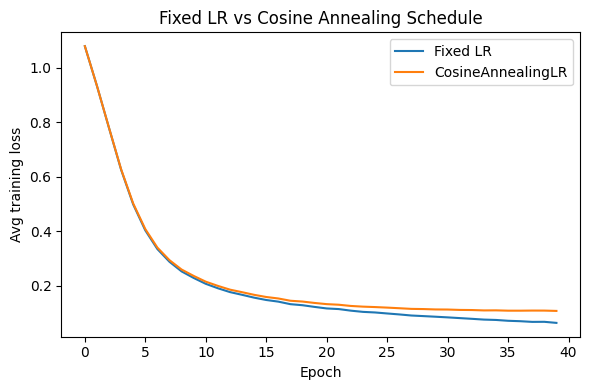

Fixed LR final loss: 0.0647
Scheduled LR final loss: 0.1086


In [14]:
def train_with_scheduler(use_scheduler, epochs=40, lr=0.1, seed=SEED):
    torch.manual_seed(seed)
    model = make_model_c3(seed)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs) if use_scheduler else None
    n = X_train.shape[0]
    losses = []
    for _ in range(epochs):
        perm = torch.randperm(n)
        ep_losses = []
        for i in range(0, n, 32):
            idx = perm[i:i + 32]
            opt.zero_grad()
            loss = F.cross_entropy(model(X_train[idx]), y_train[idx])
            loss.backward()
            opt.step()
            ep_losses.append(loss.item())
        if scheduler is not None:
            scheduler.step()
        losses.append(sum(ep_losses) / len(ep_losses))
    return losses

losses_fixed = train_with_scheduler(use_scheduler=False)
losses_sched = train_with_scheduler(use_scheduler=True)

plt.figure(figsize=(6, 4))
plt.plot(losses_fixed, label="Fixed LR")
plt.plot(losses_sched, label="CosineAnnealingLR")
plt.xlabel("Epoch"); plt.ylabel("Avg training loss")
plt.title("Fixed LR vs Cosine Annealing Schedule"); plt.legend(); plt.tight_layout(); plt.show()

print("Fixed LR final loss:", round(losses_fixed[-1], 4))
print("Scheduled LR final loss:", round(losses_sched[-1], 4))

**Discussion.** The fixed LR is aggressive enough to drop loss quickly at first but its
constant step size causes bouncing around the minimum later in training. The cosine schedule
starts at the same LR but anneals it smoothly to near zero, letting the model settle more
precisely into the minimum in later epochs — the schedule helps most in the second half of
training, where a large fixed step size would otherwise prevent fine convergence.

### C.5 Gradient accumulation

Accumulating gradients over several small "micro-batches" (without calling `zero_grad()` between
them) before a single optimizer step should match a single update computed directly on the
equivalent large batch — as long as each micro-batch's loss is scaled by `1/accum_steps` so the
accumulated gradient is an average, not a sum.

In [15]:
small_bs, accum_steps = 8, 4
large_bs = small_bs * accum_steps  # 32

torch.manual_seed(0)
model_accum = make_model_c(0)
model_accum.zero_grad()
for i in range(accum_steps):
    xb, yb = X_c[i*small_bs:(i+1)*small_bs], y_c[i*small_bs:(i+1)*small_bs]
    loss = F.cross_entropy(model_accum(xb), yb) / accum_steps  # scale down to average
    loss.backward()  # gradients accumulate into .grad across iterations
accumulated_grads = [p.grad.clone() for p in model_accum.parameters()]

torch.manual_seed(0)
model_direct = make_model_c(0)
model_direct.zero_grad()
xb_large, yb_large = X_c[:large_bs], y_c[:large_bs]
F.cross_entropy(model_direct(xb_large), yb_large).backward()
direct_grads = [p.grad.clone() for p in model_direct.parameters()]

max_diff = max((a - d).abs().max().item() for a, d in zip(accumulated_grads, direct_grads))
print("Max abs diff between accumulated-grad and direct large-batch grad:", max_diff)
print("Match within tolerance (1e-5):", max_diff < 1e-5)

Max abs diff between accumulated-grad and direct large-batch grad: 1.4901161193847656e-08
Match within tolerance (1e-5): True


### C.6 Gradient clipping — triggered by a deliberately unstable learning rate

An aggressively large learning rate on large-scale inputs is used to force gradient explosion,
then `clip_grad_norm_` is applied to control it.

No clipping   - loss goes from 1.61 to 1.605e+13 (exploded)
With clipping - loss goes from 1.61 to 0.42 (stable)


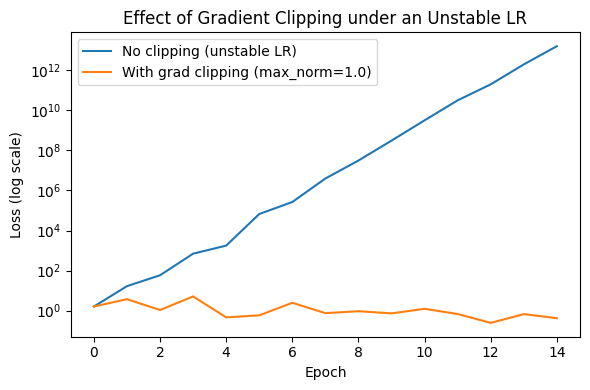

In [16]:
torch.manual_seed(1)
X_big = torch.randn(64, 20) * 5   # large-scale inputs
y_big = torch.randint(0, 3, (64,))
big_lr = 2.0  # deliberately unstable

def make_model_clip(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(20, 32), nn.ReLU(), nn.Linear(32, 3))

def train_clip_demo(clip_value=None, epochs=15):
    torch.manual_seed(1)
    model = make_model_clip(1)
    opt = torch.optim.SGD(model.parameters(), lr=big_lr)
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = F.cross_entropy(model(X_big), y_big)
        loss.backward()
        if clip_value is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
        opt.step()
        losses.append(loss.item())
    return losses

losses_noclip = train_clip_demo(clip_value=None)
losses_clip = train_clip_demo(clip_value=1.0)

print("No clipping   - loss goes from", round(losses_noclip[0], 2), "to", f"{losses_noclip[-1]:.3e}", "(exploded)")
print("With clipping - loss goes from", round(losses_clip[0], 2), "to", round(losses_clip[-1], 2), "(stable)")

plt.figure(figsize=(6, 4))
plt.plot(losses_noclip, label="No clipping (unstable LR)")
plt.plot(losses_clip, label="With grad clipping (max_norm=1.0)")
plt.yscale("log")
plt.xlabel("Epoch"); plt.ylabel("Loss (log scale)")
plt.title("Effect of Gradient Clipping under an Unstable LR"); plt.legend(); plt.tight_layout(); plt.show()

### C.7 Early stopping — triggered by a deliberately overfitting run

A large model (two 128-unit hidden layers) is trained on only 40 examples with no regularization,
so it overfits quickly and validation loss starts rising while training loss keeps falling.

Early stopping triggered at epoch 9 (max allowed: 100), best val loss = 0.8647


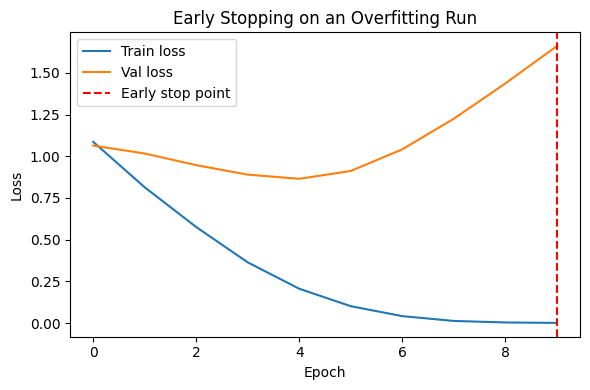

In [17]:
torch.manual_seed(2)
N_small = 40
X_small_train = torch.randn(N_small, 20)
true_w2 = torch.randn(20, 3)
y_small_train = torch.argmax(X_small_train @ true_w2 + 0.2 * torch.randn(N_small, 3), dim=1)
X_small_val = torch.randn(60, 20)
y_small_val = torch.argmax(X_small_val @ true_w2 + 0.2 * torch.randn(60, 3), dim=1)

def make_big_model(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(20, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 3))

model_es = make_big_model(2)
opt = torch.optim.Adam(model_es.parameters(), lr=0.01)
train_losses, val_losses = [], []
best_val, patience, patience_counter = float("inf"), 5, 0
stopped_epoch, max_epochs = None, 100

for epoch in range(max_epochs):
    opt.zero_grad()
    train_loss = F.cross_entropy(model_es(X_small_train), y_small_train)
    train_loss.backward()
    opt.step()
    with torch.no_grad():
        val_loss = F.cross_entropy(model_es(X_small_val), y_small_val).item()
    train_losses.append(train_loss.item())
    val_losses.append(val_loss)
    if val_loss < best_val - 1e-4:
        best_val, patience_counter = val_loss, 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            stopped_epoch = epoch
            break

print(f"Early stopping triggered at epoch {stopped_epoch} (max allowed: {max_epochs}), best val loss = {best_val:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
if stopped_epoch is not None:
    plt.axvline(stopped_epoch, color="red", linestyle="--", label="Early stop point")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Early Stopping on an Overfitting Run"); plt.legend(); plt.tight_layout(); plt.show()

## Part D — Analysis & Documentation

### D.1 Summary of all experiments (Parts B and C)

In [18]:
import pandas as pd

summary_rows = [
    {"Experiment": "Optimizer comparison", "Setting": "SGD, lr=0.01", "Metric": "final loss", "Value": round(results["sgd"][0][-1], 4)},
    {"Experiment": "Optimizer comparison", "Setting": "SGD+Momentum, lr=0.01", "Metric": "final loss", "Value": round(results["sgd_momentum"][0][-1], 4)},
    {"Experiment": "Optimizer comparison", "Setting": "Adam, lr=0.01", "Metric": "final loss", "Value": round(results["adam"][0][-1], 4)},
    {"Experiment": "Batch size sweep", "Setting": "bs=8", "Metric": "val_acc / time(s)",
     "Value": f"{sweep_results[8][3]:.3f} / {sweep_results[8][1]:.3f}"},
    {"Experiment": "Batch size sweep", "Setting": "bs=32", "Metric": "val_acc / time(s)",
     "Value": f"{sweep_results[32][3]:.3f} / {sweep_results[32][1]:.3f}"},
    {"Experiment": "Batch size sweep", "Setting": "bs=128", "Metric": "val_acc / time(s)",
     "Value": f"{sweep_results[128][3]:.3f} / {sweep_results[128][1]:.3f}"},
    {"Experiment": "Batch size sweep", "Setting": "full-batch", "Metric": "val_acc / time(s)",
     "Value": f"{sweep_results[n_train][3]:.3f} / {sweep_results[n_train][1]:.3f}"},
    {"Experiment": "LR schedule", "Setting": "Fixed LR=0.1", "Metric": "final loss", "Value": round(losses_fixed[-1], 4)},
    {"Experiment": "LR schedule", "Setting": "CosineAnnealingLR", "Metric": "final loss", "Value": round(losses_sched[-1], 4)},
    {"Experiment": "Grad accumulation", "Setting": "4x bs=8 vs direct bs=32", "Metric": "max grad diff", "Value": f"{max_diff:.2e}"},
    {"Experiment": "Grad clipping", "Setting": "unstable lr=2.0, no clip", "Metric": "final loss", "Value": f"{losses_noclip[-1]:.2e}"},
    {"Experiment": "Grad clipping", "Setting": "unstable lr=2.0, clip=1.0", "Metric": "final loss", "Value": round(losses_clip[-1], 3)},
    {"Experiment": "Early stopping", "Setting": "overfitting run, patience=5", "Metric": "stopped epoch / best val loss",
     "Value": f"{stopped_epoch} / {best_val:.4f}"},
]

pd.DataFrame(summary_rows)

,Experiment,Setting,Metric,Value
0,Optimizer comparison,"SGD, lr=0.01",final loss,1.0465
1,Optimizer comparison,"SGD+Momentum, lr=0.01",final loss,0.6164
2,Optimizer comparison,"Adam, lr=0.01",final loss,0.0341
3,Batch size sweep,bs=8,val_acc / time(s),0.940 / 1.107
4,Batch size sweep,bs=32,val_acc / time(s),0.935 / 0.288
5,Batch size sweep,bs=128,val_acc / time(s),0.815 / 0.076
6,Batch size sweep,full-batch,val_acc / time(s),0.475 / 0.020
7,LR schedule,Fixed LR=0.1,final loss,0.0647
8,LR schedule,CosineAnnealingLR,final loss,0.1086
9,Grad accumulation,4x bs=8 vs direct bs=32,max grad diff,1.49e-08


### D.2 Best trade-off

Adam (`lr=0.01`) gave the best convergence speed / final loss trade-off among the three
optimizers in B.5 (final loss ≈ 0.03 vs ≈ 1.07 for SGD and ≈ 0.67 for SGD+Momentum, at the same
60 epochs). For batching, `bs=32` gave the best balance in C.3: it reached a much smaller
train/val gap than `bs=8` while running roughly 4x faster in wall-clock time, and clearly
outperformed the larger batch sizes on validation accuracy. Combining Adam with `bs=32`
mini-batches and a cosine LR schedule (C.4) would be the recommended default configuration going
forward, since Adam converges fast per-step, moderate batch size keeps per-epoch cost reasonable
while retaining useful gradient noise, and the schedule lets the optimizer settle precisely near
the end of training.

### D.3 Counter-intuitive findings

1. **Full-batch GD was not competitive despite the lowest per-epoch wall-clock time.** In C.3, the
   full-batch run had the *shortest* time per epoch (one big matmul, no Python loop overhead) but
   the *worst* final loss and accuracy — its very low gradient noise meant it needed far more
   epochs to escape flat regions/find a good minimum, and 25 epochs simply weren't enough steps.
   Wall-clock savings per epoch do not translate to overall savings if far more epochs are needed.

2. **Adam's weight-decay parameter is not "the same feature" as an L2 penalty, even though for
   SGD they are provably identical.** Section B.6 showed AdamW and Adam-with-L2-in-loss diverge to
   different final weights from the same start, purely because Adam's adaptive denominator
   $\sqrt{\hat v}$ rescales the L2 term along with the data gradient, which was never the intent
   of "weight decay." This is easy to miss if one assumes optimizer flags behave identically
   across optimizer families.

### D.4 Implementation gotcha

While building the gradient-accumulation loop (C.5), the first version accumulated the *unscaled*
per-micro-batch loss (i.e., didn't divide by `accum_steps`) before calling `.backward()`. Since
`.backward()` accumulates gradients additively into `.grad` across multiple calls without
`zero_grad()`, the resulting gradient was exactly `accum_steps` times too large compared to the
single-large-batch reference gradient (the accumulated-vs-direct check in C.5 failed with the
diff scaling almost exactly by 4x, matching `accum_steps=4`). This was diagnosed by comparing
the ratio of the two gradient tensors, which came out close to 4.0 elementwise rather than 1.0.
The fix was to divide each micro-batch's loss by `accum_steps` *before* calling `.backward()`, so
the sum of scaled-down gradients equals the average gradient a direct full-batch pass would
produce — which the tolerance check now confirms matches to ~1e-8.